# 准备操作

In [50]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 指定默认字体为黑体（SimHei），解决中文乱码
plt.rcParams['font.sans-serif'] = ['SimHei']

data_dir = r'D:\Coding\Code\Python3\west2_online\data_science\info.csv'
info = pd.read_csv(data_dir)

# 分析通知人都是谁以及发布通知的次数

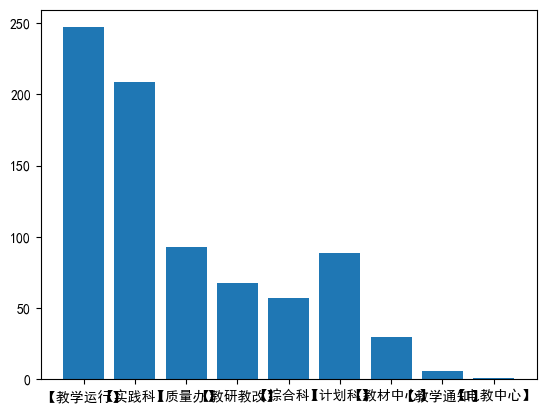

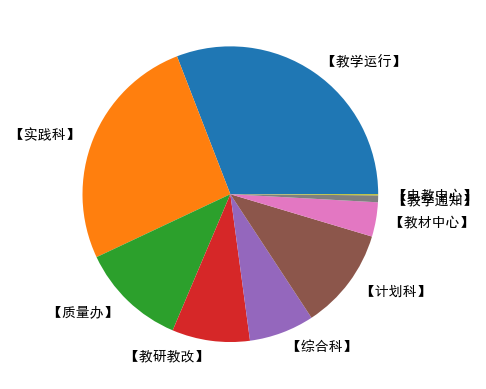

In [51]:
def author_stat(data:pd.DataFrame):
    # 统计科室有谁，每个出现的次数
    d:dict = {}

    series = data['科室']
    for name in series:
        if name in d:
            d[name] += 1
        else:
            d[name] = 1 
             
    # picture
    x = np.array(list(d.keys()))
    y = np.array(list(d.values()))
    plt.bar(x,y)
    plt.show()

    plt.pie(y,labels=x)

author_stat(info)

# 分析通知人和附件下载次数关系

没有附件的不用分析

In [52]:
info_tmp = info

# 清洗下载次数为空的项（无附件）
info_tmp = info_tmp.dropna()

下载附件有多个的，我们分析为：
    下载次数特征为学生看到该通知后*选择*下载附件的行为，来表示学生选择查看该科室的通知以及下载附件的意愿
    所以多值项取下载次数最高的为下载量
    由于 下载所有附件 这一行为是常见的，所以不采取所有值求和的方法
以上：    
    将下载次数为多值项的替换为最高下载次数，最后对各个科室以通知数量来求下载量平均值，画出条形图

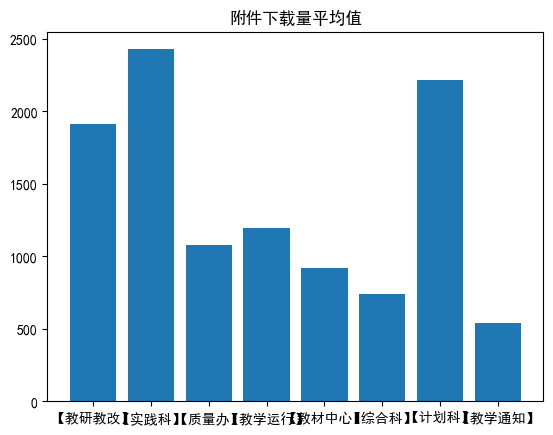

In [59]:
def analysis_download(data:pd.DataFrame):
    d:dict = {}
    download = info_tmp['附件下载次数']
    author = info_tmp['科室']

    for name,times in zip(author,download):
        if name in d:
            d[name][0] += 1
        else:
            d[name] = [1,0] 
        
        import ast
        times = ast.literal_eval(times)
        times = list(map(int,times))

        if len(times)>1:
            times=[max(times)]

        d[name][1] += times[0]

    d_tmp = {}
    for i in d:
        value = d[i][1] / d[i][0]
        d_tmp[i] = value

    x = list(d_tmp.keys())
    y = list(d_tmp.values())
    plt.title('附件下载量平均值')
    plt.bar(x,y)
    plt.show()

analysis_download(info_tmp)


根据图表可得，实践科、计划科、教研教改所发表的通知中的附件更多得被下载

# 通知的高峰期
现将每年以月为最小单位进行统计，研究通知发表量在一年的分布密度

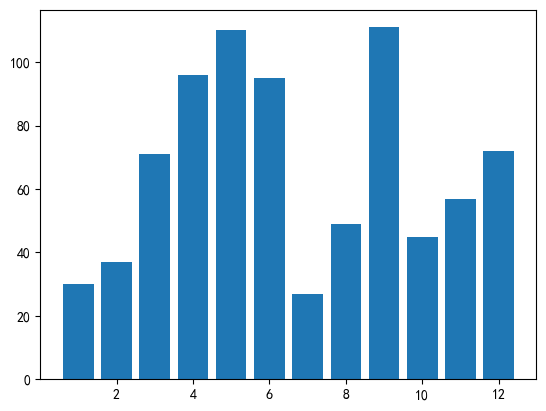

In [66]:
def analysis_date(data:pd.DataFrame):
    date_series = data['发布日期']

    d = {
        x:0 for x in range(1,13)
    }
    
    from datetime import datetime

    for date in date_series:
        dt = datetime.strptime(date,'%Y-%m-%d')
        
        d[dt.month] += 1

    x = list(d.keys())
    y = list(d.values())

    plt.bar(x,y)
    plt.show()
    
analysis_date(info)

由图得各个月份的发布通知数量，下学期起止为3月至6月，上学期为9月至1月
- 1.下学期发布通知量高于上学期
- 2.学期中间的月份发布通知高于开始和结束
- 3.特别的，上学期开学初（9月）发布的通知特别多，属于一年中最多的月份